# K-Means Clustering — Alzheimer's Biomarker Data

Approaching the same biomarker dataset unsupervised: standardizing features and reducing dimensionality with PCA, then clustering with K-Means (cluster count chosen via the elbow method) to see whether the same CN/AD structure emerges on its own, without ever showing the model the diagnostic labels.

## 1. Load and preprocess the data (Standard Scaler + PCA)

In [2]:
# Import some libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# load the AD dataset
df = pd.read_csv('AD-dataset.csv')
df.head()

,Unnamed: 0,RID,AGE,PTGENDER,WHOLECEREBELLUM_VOLUME,LEFT_HIPPOCAMPUS_SUVR,LEFT_HIPPOCAMPUS_VOLUME,RIGHT_HIPPOCAMPUS_SUVR,RIGHT_HIPPOCAMPUS_VOLUME,LEFT_AMYGDALA_SUVR,...,CTX_LH_ENTORHINAL_VOLUME,CTX_RH_BANKSSTS_SUVR,CTX_RH_BANKSSTS_VOLUME,CTX_RH_ENTORHINAL_SUVR,CTX_RH_ENTORHINAL_VOLUME,ABETA_bl,TAU_bl,PTAU_bl,DX_bl,DX_lon
0,1,23,71.7,Male,142109,1.286,4172,1.236,4236,1.180,...,1913,1.424,1749,0.909,1933,1647,181.1,16.74,CN,sCN
1,2,31,77.7,Female,103642,1.004,3605,1.097,3145,0.965,...,1244,1.375,1813,0.963,1398,>1700,266.8,22.55,CN,sCN
2,4,42,72.8,Male,122034,0.729,2323,0.751,1848,0.931,...,1052,1.108,1511,0.845,1480,1258,250.1,18.23,MCI,cMCI
3,5,47,84.7,Male,122574,0.906,3437,0.900,3069,0.933,...,2213,1.164,1824,0.815,1842,1410,224.4,21.4,CN,sCN
4,8,56,69.6,Female,116393,1.089,3808,1.079,3777,0.897,...,1887,1.105,1645,0.792,1652,1048,128.2,12.23,CN,cCN


In [3]:
### DATA PREPROCESSING ###
# Select columns
df = df.iloc[:, 2:]
df = df.drop (columns = ['DX_lon'])

# manipulate columns
df['PTGENDER'] = df['PTGENDER'].map({'Male': 0, 'Female': 1})
df['ABETA_bl'] = df['ABETA_bl'].replace({'>1700': 1700})
df['ABETA_bl'] = pd.to_numeric(df['ABETA_bl'], errors='coerce')
df['PTAU_bl'] = df['PTAU_bl'].replace({'<8': 8})
df['PTAU_bl'] = pd.to_numeric(df['PTAU_bl'], errors='coerce')
df.dropna(subset=['ABETA_bl'], inplace=True) # inplace=True to overwrite df

In [6]:
# drop the MCIs from the df (work only with two classes)
df_CN_AD = df[df['DX_bl'] != 'MCI']

# Get target names before dropping the column
target_names = df_CN_AD['DX_bl'].unique()

# feature data in X
X_AD = df_CN_AD.drop('DX_bl', axis=1)
# label data in y. Use 0/1 mapping
y = df_CN_AD['DX_bl'].map({'CN': 0, 'AD': 1})

In [9]:
# Standardize tha data
scaler_AD = StandardScaler()
X_AD_scaled = scaler_AD.fit_transform(X_AD)

# Apply PCA to represent the data in 2 variables
pca_AD = PCA(n_components=2)
X_df_AD = pca_AD.fit_transform(X_AD_scaled)

## 2. Kmeans clustering algorithm implementation and finding the optimum number of clusters

Text(0.5, 1.0, 'KMeans clustering plot')

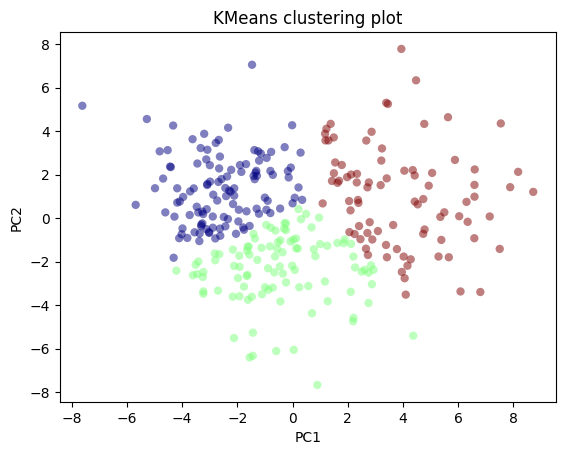

In [12]:
from sklearn.cluster import KMeans

# KMeans with an arbitrary number of clusters, for example K = 3
km = KMeans(n_clusters=3, init="k-means++", n_init=10)
km_pred = km.fit_predict(X_df_AD)
labels = km.labels_

plt.figure()
plt.scatter(X_df_AD[:,0], X_df_AD[:,1], c=km_pred, cmap="jet",
            edgecolor="None", alpha=0.50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("KMeans clustering plot")


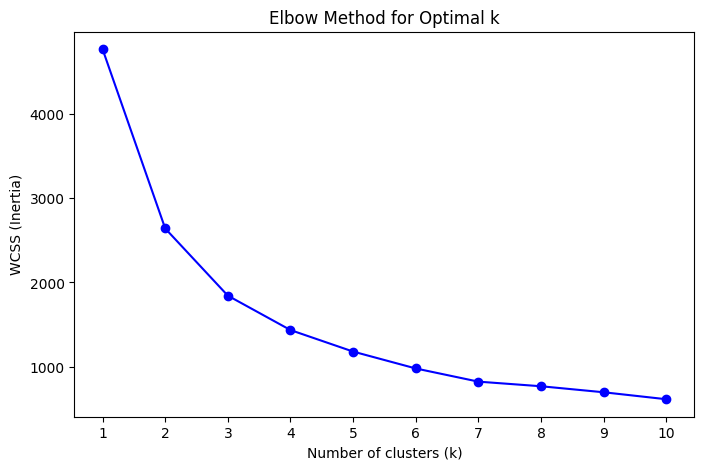

In [13]:
### SEARCH FOR THE OPTIMUM NUMBER OF CLUSTERS USING ELBOW METHOD ###
# Range of k values to test
k_values = range(1, 11)

# Store the within-cluster sum of squares for each k
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_df_AD)
    wcss.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_values)
plt.show()

# It is very hard to say where is the elbow, so we will use Silhouette

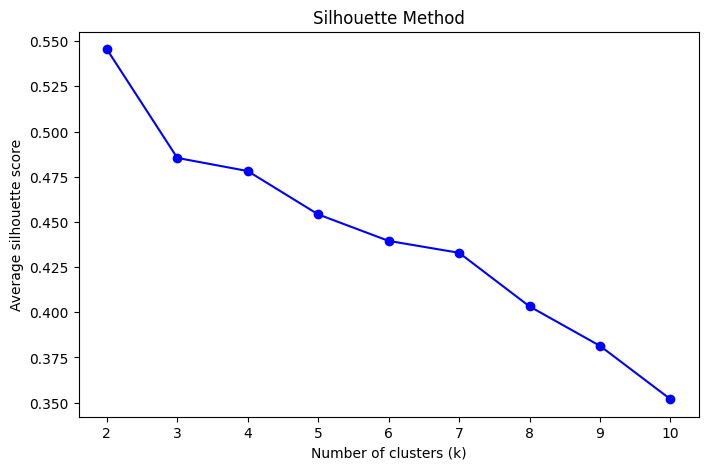

In [14]:
### SEARCH FOR THE OPTIMUM NUMBER OF CLUSTERS USING SILHOUETTE METHOD ###
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X_AD)
    score = silhouette_score(X_AD, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average silhouette score')
plt.title('Silhouette Method')
plt.show()

# After the two methods, it seems that the optimum number of clusters to
# describe the data is 2.

Text(0.5, 1.0, 'KMeans clustering plot')

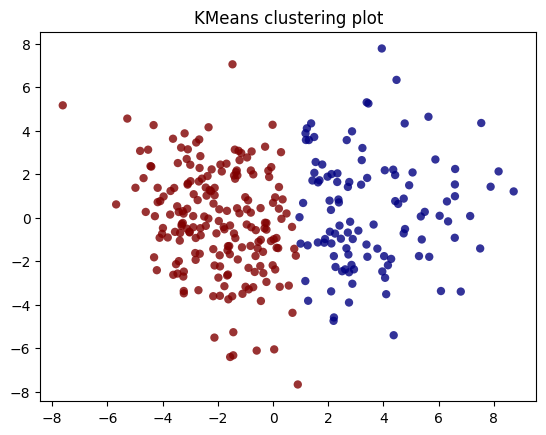

In [15]:
# Repeat Kmeans clustering but with 2 clusters
km = KMeans(n_clusters=2, init="k-means++", n_init=10)
km_pred = km.fit_predict(X_df_AD)
labels = km.labels_

plt.figure()
plt.scatter(X_df_AD[:,0], X_df_AD[:,1], c=km_pred, cmap="jet", edgecolor="None", alpha=0.8)
plt.title("KMeans clustering plot")

## 3. Results interpretation

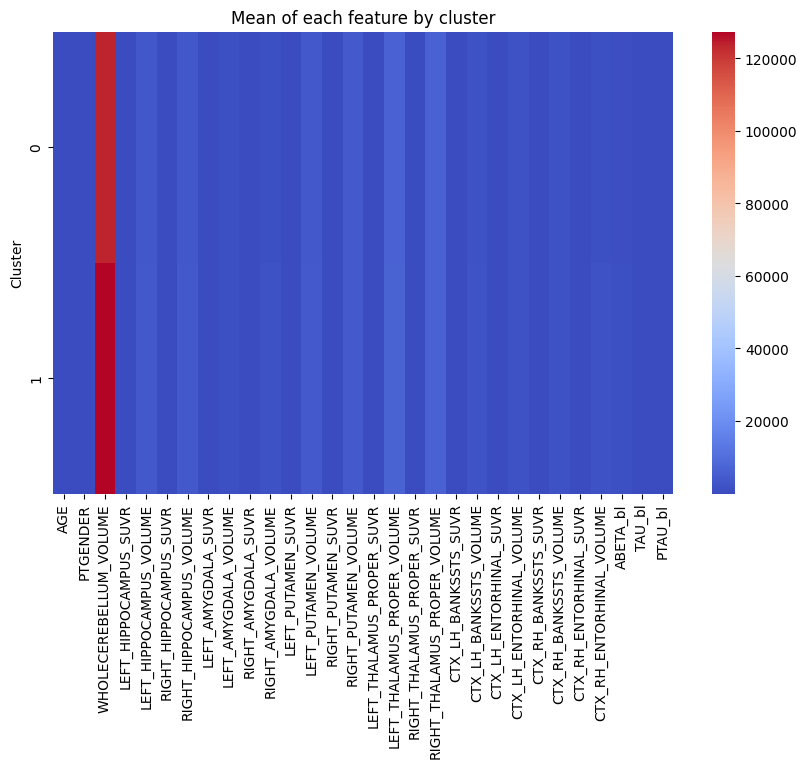

In [18]:
# Inspect the mean characteristics of the 2 different groups

df_AD = pd.DataFrame(X_AD, columns=X_AD.columns)

# Add the cluster assigned to each sample
df_AD['Cluster'] = labels

# Compute mean of each feature for each cluster
cluster_means = df_AD.groupby('Cluster').mean()


plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means, cmap='coolwarm')
plt.title('Mean of each feature by cluster')
plt.show()

# This plot is not so informative

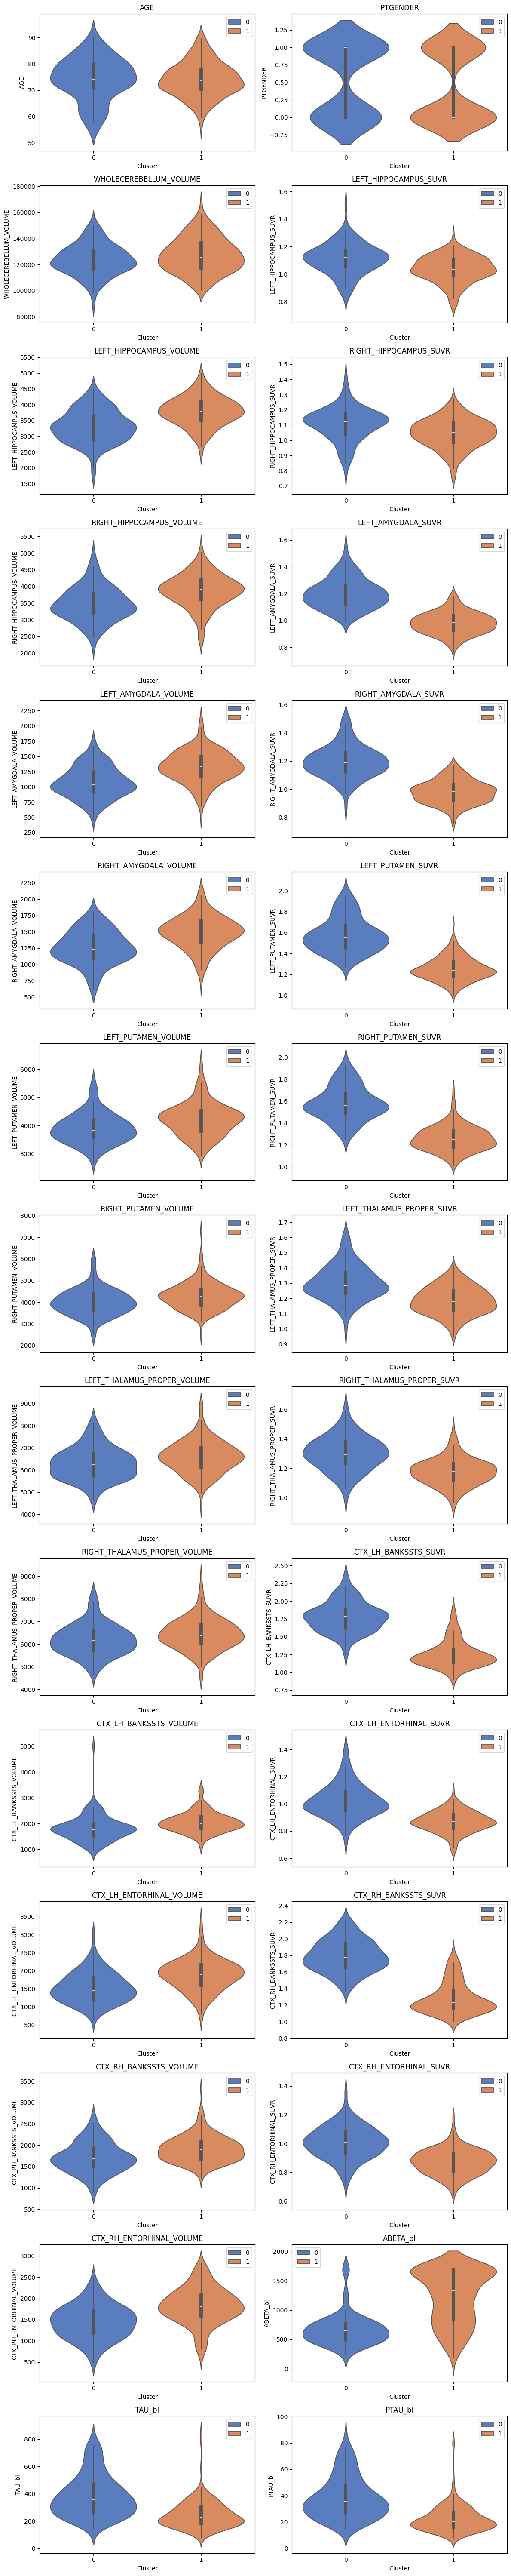

In [19]:
# Explore features between groups
# List of features excluding 'Cluster'
features = [col for col in df_AD.columns if col != 'Cluster']

# Number of features
n = len(features)

# Set up the figure size and grid layout (e.g., 2 columns)
cols = 2
rows = (n + 1) // cols  # integer division ceiling

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()  # flatten in case of 2D axes

for i, col in enumerate(features):
    sns.violinplot(data=df_AD, x='Cluster', palette='muted',
                   hue=labels, y=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Here we have really interesting violin plots

## SHORT INTERPRETATION
The clustering analysis using KMeans with 2 clusters appears to distinguish between two groups based on brain imaging and biomarker data. Cluster 0 is characterized by lower brain volumes and higher levels of Tau proteins (TAU_bl, PTAU_bl), while Cluster 1 shows larger brain volumes and higher levels of Amyloid-Beta (ABETA_bl). These differences suggest the clusters may have correctly classified Alzheimer's Disease pathology according to the outcome or clinical diagnosis we already had. Cluster 0 could potentially correspond to individuals with diagnosed AD, and Cluster 1 to those with CN diagnosis.